**Name: Jonathan Leong**         
**CLass: PE01**         
**Admin Number: 2401458A**

# **Preparing Workers Productivity dataset for use through Data Cleaning** # 

**Import all the required libraries at the start:**


In [3766]:
import warnings
warnings.simplefilter(action="ignore")

#The following libraries are for reading the dataset:
import numpy as np
import pandas as pd
import sklearn.metrics as metrics


#Used for plotting graphs:
import matplotlib.pyplot as plt

import seaborn as sns

#for classification model
from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

#for boosted SVM
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

from sklearn.neighbors import KNeighborsClassifier

In [3630]:
data = pd.read_csv("./dataset/Workers_Productivity.csv")
print(data.head())
print("\n")

       date   quarter  department       day  team  targeted_productivity  \
0  1/1/2015  Quarter1      sewing  Thursday     8                   0.80   
1  1/1/2015  Quarter1  finishing   Thursday     1                   0.75   
2  1/1/2015  Quarter1      sewing  Thursday    11                   0.80   
3  1/1/2015  Quarter1      sewing  Thursday    12                   0.80   
4  1/1/2015  Quarter1      sewing  Thursday     6                   0.80   

     smv     wip  over_time  incentive  idle_time  idle_men  \
0  26.16  1108.0       7080         98        0.0         0   
1   3.94     NaN        960          0        0.0         0   
2  11.41   968.0       3660         50        0.0         0   
3  11.41   968.0       3660         50        0.0         0   
4  25.90  1170.0       1920         50        0.0         0   

   no_of_style_change  no_of_workers  actual_productivity productivity  
0                   0           59.0             0.940725         high  
1                 

# **Data Cleaning** #

In [3631]:
#The code in this block is to check if there is any duplicate data in this dataset
duplicates = data[data.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [date, quarter, department, day, team, targeted_productivity, smv, wip, over_time, incentive, idle_time, idle_men, no_of_style_change, no_of_workers, actual_productivity, productivity]
Index: []


**As there is no duplicated data in this dataset, there is no duplicate data to remove with data.drop_duplicates() .**

In [3632]:
print(data.describe())

              team  targeted_productivity          smv           wip  \
count  1197.000000            1197.000000  1197.000000    691.000000   
mean      6.426901               0.729632    15.062172   1190.465991   
std       3.463963               0.097891    10.943219   1837.455001   
min       1.000000               0.070000     2.900000      7.000000   
25%       3.000000               0.700000     3.940000    774.500000   
50%       6.000000               0.750000    15.260000   1039.000000   
75%       9.000000               0.800000    24.260000   1252.500000   
max      12.000000               0.800000    54.560000  23122.000000   

          over_time    incentive    idle_time     idle_men  \
count   1197.000000  1197.000000  1197.000000  1197.000000   
mean    4567.460317    38.210526     0.730159     0.369256   
std     3348.823563   160.182643    12.709757     3.268987   
min        0.000000     0.000000     0.000000     0.000000   
25%     1440.000000     0.000000     0.00

**As the statistic infomation of the "incentive" column looked slightly weird based on its min, max and mean value, 
I decided to manually look through the values from the csv and found the following strange rows:**

In [3633]:
#print(data[1128:1131],"\n", data[1133:1134],"\n", data[1137:1140],"\n", data[1143:1144],"\n", data[1148:1150])
print(data[["over_time", "incentive"]][1128:1131],"\n", data[["over_time", "incentive"]][1133:1134],"\n", data[["over_time", "incentive"]][1137:1140],"\n", data[["over_time", "incentive"]][1143:1144],"\n", data[["over_time", "incentive"]][1148:1150])

      over_time  incentive
1128          0        960
1129          0       1080
1130          0       2880 
       over_time  incentive
1133          0       3600 
       over_time  incentive
1137          0       1440
1138          0        960
1139          0        960 
       over_time  incentive
1143          0       1200 
       over_time  incentive
1148          0        960
1149          0        960


**After looking at these rows, I found out that the information for these 10 rows is swapped for the over_time and incentive rows
Hence, I did the following code in the next 2 code blocks to swap the data of the "over_time" and "incentive" columns for the affected rows.**

In [3634]:
data["over_time"][1128:1131] = data["incentive"][1128:1131]
data["over_time"][1133:1134] = data["incentive"][1133:1134]
data["over_time"][1137:1140] = data["incentive"][1137:1140]
data["over_time"][1143:1144] = data["incentive"][1143:1144]
data["over_time"][1148:1150] = data["incentive"][1148:1150]
print(data[["over_time", "incentive"]][1128:1131],"\n", data[["over_time", "incentive"]][1133:1134],"\n", data[["over_time", "incentive"]][1137:1140],"\n", data[["over_time", "incentive"]][1143:1144],"\n", data[["over_time", "incentive"]][1148:1150])

      over_time  incentive
1128        960        960
1129       1080       1080
1130       2880       2880 
       over_time  incentive
1133       3600       3600 
       over_time  incentive
1137       1440       1440
1138        960        960
1139        960        960 
       over_time  incentive
1143       1200       1200 
       over_time  incentive
1148        960        960
1149        960        960


In [3635]:
data["incentive"][1128:1131] = 0
data["incentive"][1133:1134] = 0
data["incentive"][1137:1140] = 0
data["incentive"][1143:1144] = 0
data["incentive"][1148:1150] = 0
print(data[["over_time", "incentive"]][1128:1131],"\n", data[["over_time", "incentive"]][1133:1134],"\n", data[["over_time", "incentive"]][1137:1140],"\n", data[["over_time", "incentive"]][1143:1144],"\n", data[["over_time", "incentive"]][1148:1150])

      over_time  incentive
1128        960          0
1129       1080          0
1130       2880          0 
       over_time  incentive
1133       3600          0 
       over_time  incentive
1137       1440          0
1138        960          0
1139        960          0 
       over_time  incentive
1143       1200          0 
       over_time  incentive
1148        960          0
1149        960          0


In [3636]:
#To see the statistics of the data of the partially cleaned data
print(data.describe())

              team  targeted_productivity          smv           wip  \
count  1197.000000            1197.000000  1197.000000    691.000000   
mean      6.426901               0.729632    15.062172   1190.465991   
std       3.463963               0.097891    10.943219   1837.455001   
min       1.000000               0.070000     2.900000      7.000000   
25%       3.000000               0.700000     3.940000    774.500000   
50%       6.000000               0.750000    15.260000   1039.000000   
75%       9.000000               0.800000    24.260000   1252.500000   
max      12.000000               0.800000    54.560000  23122.000000   

          over_time    incentive    idle_time     idle_men  \
count   1197.000000  1197.000000  1197.000000  1197.000000   
mean    4579.991646    25.679198     0.730159     0.369256   
std     3335.480597    30.375119    12.709757     3.268987   
min        0.000000     0.000000     0.000000     0.000000   
25%     1440.000000     0.000000     0.00

In [3637]:
#Display rows with missing values
missing_data = data[data.isnull().any(axis=1)]
print("Rows with Missing Data:")
print(missing_data)
print("\n")
print(missing_data.describe())

Rows with Missing Data:
           date   quarter  department        day  team  targeted_productivity  \
1      1/1/2015  Quarter1  finishing    Thursday     1                   0.75   
6      1/1/2015  Quarter1  finishing    Thursday     2                   0.75   
13     1/1/2015  Quarter1  finishing    Thursday    10                   0.65   
14     1/1/2015  Quarter1  finishing    Thursday     8                   0.75   
15     1/1/2015  Quarter1  finishing    Thursday     4                   0.75   
...         ...       ...         ...        ...   ...                    ...   
1192  3/11/2015  Quarter2   finishing  Wednesday    10                   0.75   
1193  3/11/2015  Quarter2   finishing  Wednesday     8                   0.70   
1194  3/11/2015  Quarter2   finishing  Wednesday     7                   0.65   
1195  3/11/2015  Quarter2   finishing  Wednesday     9                   0.75   
1196  3/11/2015  Quarter2   finishing  Wednesday     6                   0.70   

   

In [3638]:
missing_data.info()
#data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 506 entries, 1 to 1196
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   506 non-null    object 
 1   quarter                506 non-null    object 
 2   department             506 non-null    object 
 3   day                    506 non-null    object 
 4   team                   506 non-null    int64  
 5   targeted_productivity  506 non-null    float64
 6   smv                    506 non-null    float64
 7   wip                    0 non-null      float64
 8   over_time              506 non-null    int64  
 9   incentive              506 non-null    int64  
 10  idle_time              506 non-null    float64
 11  idle_men               506 non-null    int64  
 12  no_of_style_change     506 non-null    int64  
 13  no_of_workers          506 non-null    float64
 14  actual_productivity    506 non-null    float64
 15  productivi

**From the use of missing_data.info(), I can tell that the only missing data in my dataset is wip**
**I will use pd.unique() to figure out what are some of the most common values in each column in the missing_data dataframe**

In [3639]:
pd.unique(missing_data["quarter"])

array(['Quarter1', 'Quarter2', 'Quarter3', 'Quarter4', 'Quarter5'],
      dtype=object)

In [3640]:
pd.unique(missing_data["department"])

array(['finishing ', 'finishing'], dtype=object)

In [3641]:
pd.unique(missing_data["day"])

array(['Thursday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday'],
      dtype=object)

In [3642]:
np.sort(pd.unique(missing_data["team"]))

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [3643]:
pd.unique(missing_data["targeted_productivity"])

array([0.75, 0.65, 0.8 , 0.7 , 0.6 , 0.5 , 0.35, 0.4 ])

In [3644]:
pd.unique(missing_data["smv"])

array([3.94, 2.9 , 4.15, 4.3 , 4.08, 5.13, 4.6 , 3.9 ])

In [3645]:
pd.unique(missing_data["over_time"])

array([  960,  2160,  1440,  6600,  5640,  1560,  4320,  1920,  2400,
        3840,  4440,  1800,  2700, 12600,   900,  2760,  6000,  3600,
        3240,  5400,  1620,  1980,  1260,  3420,  5040,  5100,  8400,
        9000, 15000,  4800, 12000,  3060,  2520,   720,  3780,  1080,
        1200,   240,   600,  2280,  1320,  3000,  2640,  2880,  6300,
        7560,  3360, 10500, 10080,  4200])

In [3646]:
pd.unique(missing_data["incentive"])

array([0])

In [3647]:
pd.unique(missing_data["idle_time"])

array([0.])

In [3648]:
pd.unique(missing_data["idle_men"])

array([0])

In [3649]:
pd.unique(missing_data["no_of_style_change"])

array([0])

In [3650]:
pd.unique(missing_data["no_of_workers"])

array([ 8., 18., 12., 20., 17., 10., 16., 15.,  5.,  2.,  9.,  7., 19.,
       28., 14., 25.,  4., 21., 11., 22., 24.,  6.])

In [3651]:
pd.unique(missing_data["actual_productivity"])

array([0.8865    , 0.75516667, 0.70591667, 0.67666667, 0.59305556,
       0.54072917, 0.43632639, 0.98802469, 0.98788044, 0.95627083,
       0.94527778, 0.90291667, 0.78244792, 0.7018125 , 0.62833333,
       0.6253125 , 0.99138889, 0.93164583, 0.91522917, 0.86167901,
       0.79210417, 0.75922839, 0.68270833, 0.66760417, 0.34583333,
       0.96105903, 0.93951389, 0.89366319, 0.87539062, 0.82083333,
       0.80441667, 0.763375  , 0.75927083, 0.66458333, 0.96678135,
       0.93649621, 0.89916667, 0.88868687, 0.85814394, 0.80964015,
       0.80590909, 0.68106061, 0.61625   , 0.95142046, 0.8805303 ,
       0.83      , 0.82718654, 0.81337121, 0.80464015, 0.66651515,
       0.33011364, 0.94768939, 0.9199054 , 0.89172348, 0.83575758,
       0.82135417, 0.77979167, 0.73598485, 0.71262626, 0.51560606,
       0.985     , 0.93034038, 0.91158974, 0.84695076, 0.81742424,
       0.81710227, 0.67007576, 0.62888258, 0.33797349, 0.93532197,
       0.92564394, 0.87306818, 0.82829546, 0.66808712, 0.65359

In [3652]:
pd.unique(missing_data["productivity"])

array(['high', 'medium', 'low'], dtype=object)

**The info I have gathered from pd.unique() above is that:**
**All my missing_data rows belong to the "finishing" department, have 0 incentive, 0 idle_time, 0 idle_men and 0 no_of_style_change, while the rest of the rows without the missing value belong to the "sewing" department.**

**From a quick search on Google, I have also found out that wip also means work in progress**
https://dictionary.cambridge.org/dictionary/english/wip

**I decided to fill all the missing wip values with 0, as I cannot use .mean() as all the other wip values are all tied to sewing; none of them are tied to finishing**
**Additionally, because the column of "wip" means work in progress, I inferred that a reason why all the "wip" values are null is that they were either not needed or the values are just 0, so they were not recorded**
**Another reason why I feel that the value should be 0 is that the department is called "finishing" and it would make sense if the "wip" column is filled with the value 0 if the workers in the "finishing" have finished working on all the products.**

In [3653]:
data["wip"] = data["wip"].fillna(0)
print(data)

           date   quarter  department        day  team  targeted_productivity  \
0      1/1/2015  Quarter1      sewing   Thursday     8                   0.80   
1      1/1/2015  Quarter1  finishing    Thursday     1                   0.75   
2      1/1/2015  Quarter1      sewing   Thursday    11                   0.80   
3      1/1/2015  Quarter1      sewing   Thursday    12                   0.80   
4      1/1/2015  Quarter1      sewing   Thursday     6                   0.80   
...         ...       ...         ...        ...   ...                    ...   
1192  3/11/2015  Quarter2   finishing  Wednesday    10                   0.75   
1193  3/11/2015  Quarter2   finishing  Wednesday     8                   0.70   
1194  3/11/2015  Quarter2   finishing  Wednesday     7                   0.65   
1195  3/11/2015  Quarter2   finishing  Wednesday     9                   0.75   
1196  3/11/2015  Quarter2   finishing  Wednesday     6                   0.70   

        smv     wip  over_t

In [3654]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    1197 non-null   float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
 15  prod

**I chose not to drop the rows with missing data in my dataset earlier, as I would be dropping close to half of the data in the dataset, and I did not drop the "wip" column, as I felt that it was important to help predict productivity**

**Additionally, after finding out that all the missing data of the "wip" column was solely linked to the "finishing" department, I could not realistically drop the rows with missing "wip" data or the "wip" data column at all as it would make the data for my prediction inccurate.**

In [3655]:
##Earlier, when I used pd.unique(missing_data["department"]), I found out that there were 2 "finishing" outputs, 
##one of which had a whitespace at the end, so I decided to run the following lines of code to display the outputs in the "department" column 
##to make sure that I remove all the whitespaces to ensure data consistency.
pd.unique(data["department"])

array(['sewing', 'finishing ', 'finishing'], dtype=object)

In [3656]:
data["department"] = data["department"].str.strip()
pd.unique(data["department"])

array(['sewing', 'finishing'], dtype=object)

In [3939]:
#Create a csv file of the cleaned dataset:
data.to_csv("Cleaned_Workers_Productivity_Dataset.csv")

# **Data Analysis of Cleaned Data** #

**Analysis of the column names:**

date - The date on which the data of the worker's productivity and how much work is still left is taken on.

quarter - The quarter represents which quarter of the month it currently is, with each quarter consisting of 7 days.

department - The department in which the workers are working, either in the sewing or finishing department.

day - The day of the week on which the workers are working.

team - The team number which the workers are assigned to.

target_productivity - The expected productivity that the employers want the workers to reach on that day.

smv  - The standard minute value represents how much time (in minutes, as there are decimal values) allocated to complete one measure of work. https://www.coatsdigital.com/en/blog/defining-standard-time/

wip - The work in progress represents the number of products that are not completed, and workers are still working on them.  https://dictionary.cambridge.org/dictionary/english/wip

over_time - The amount of overtime in terms of minutes, as the numbers in the dataset are in multiples of 60 and mostly in the thousands.

incentive - The amount of money given to workers to motivate them to work harder to produce more productivity.

idle_time - The amount of time the workers are not working.

idle_men - The number of workers who are idling and not working; unproductive workers.

no_of_style_change - The number of changes in production style that took place that day.

no_of_workers - The number of workers working that day.

actual_productivity - The actual productivity score or rate which the workers achieved on that day.

productivity - The productivity category which the workers reached that day. The categories are "high", "medium" and "low".

**Deeper Analysis of the data:**

In the month of January, there is a 5th quarter which is only for the 29th and 31th day of January; the 30th day is not included as it is a Friday and Friday is a rest day.

From the use of pd.unique on the column "day" above, I have found that there is no records of Fridays, this tells me that Friday is an off day.

From the use of pd.unique on the column "department" above, I have found that there are only 2 departments, sewing and finishing.

From the use of pd.unique on the column "team" above, I have found that there are a total of 12 teams.

In the no_of_workers column, there are some rows of data with a .5 value in them. This tells me that there is at least one worker who took a half-day shift that day.



# **EDA** #

In [3657]:
#Data correlation for numerical data
data_correlation = data.drop(columns = ["date", "quarter", "department", "day", "team", "productivity"])

In [3658]:
data_correlation.corr()

,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
targeted_productivity,1.000000,-0.069489,0.019035,-0.089312,0.216804,-0.056181,-0.053818,-0.209294,-0.084288,0.421594
smv,-0.069489,1.000000,0.322704,0.673670,0.602191,0.056863,0.105901,0.315388,0.912176,-0.122089
wip,0.019035,0.322704,1.000000,0.275929,0.387456,-0.005101,-0.007119,0.053293,0.373908,0.047389
over_time,-0.089312,0.673670,0.275929,1.000000,0.536846,0.030946,-0.018410,0.058708,0.733113,-0.053574
incentive,0.216804,0.602191,0.387456,0.536846,1.000000,-0.039686,-0.064840,0.004809,0.697547,0.310481
idle_time,-0.056181,0.056863,-0.005101,0.030946,-0.039686,1.000000,0.559146,-0.011598,0.058049,-0.080851
idle_men,-0.053818,0.105901,-0.007119,-0.018410,-0.064840,0.559146,1.000000,0.133632,0.106946,-0.181734
no_of_style_change,-0.209294,0.315388,0.053293,0.058708,0.004809,-0.011598,0.133632,1.000000,0.327787,-0.207366
no_of_workers,-0.084288,0.912176,0.373908,0.733113,0.697547,0.058049,0.106946,0.327787,1.000000,-0.057991
actual_productivity,0.421594,-0.122089,0.047389,-0.053574,0.310481,-0.080851,-0.181734,-0.207366,-0.057991,1.000000


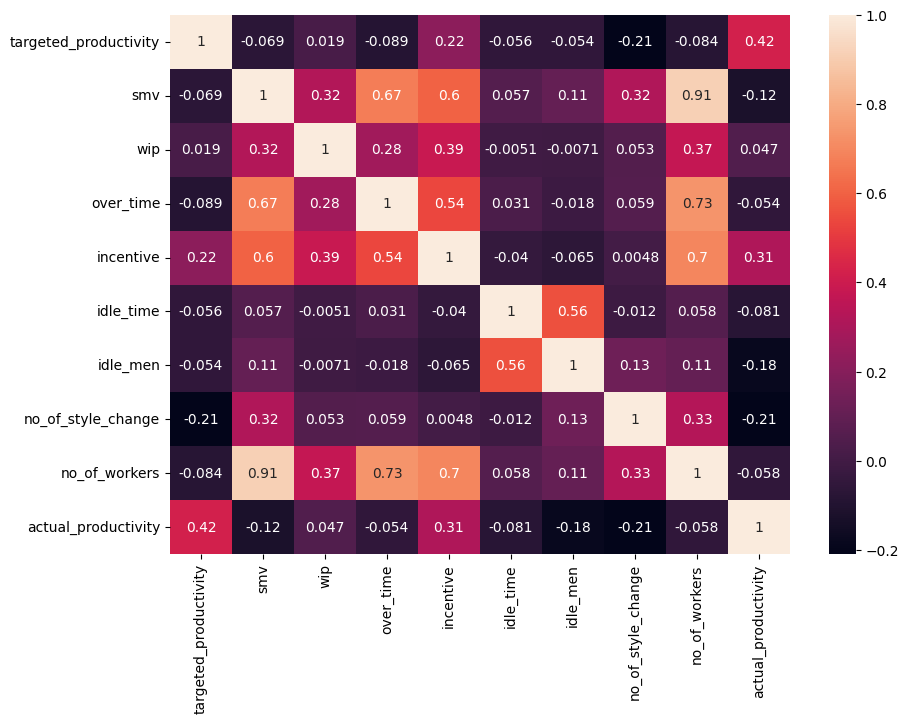

In [3659]:
sns.heatmap(data_correlation.corr(), annot = True)
plt.rcParams['figure.figsize'] = (10,7) 

## **Correlation matrix Insight** ##

**Background context: My dataset has an actual_productivity column that is a numerical datatype (float) and a productivity column that is currently an object datatype, which I will convert to a categorical datatype. With my project goal of predicting the productivity output, I am able to use the actual_productivity data column in the correlation matrix/heatmap above.**

**From this correlation matrix, I found out that I have 2 variables, targeted_productivity and incentive, that have a medium positive correlation to my productivity target, with a correlation of 0.42 and 0.31, respectively. Whereas all my other numerical data types are weakly correlated to productivity, with a correlation below +/- 0.25.**



## **1st Data transformation**  - **converting all the object data types into their correct data types such as date and category**

In [3660]:
data["date"] = pd.to_datetime(data["date"])
data["quarter"] = data["quarter"].astype("category")
data["department"] = data["department"].astype("category")
data["day"] = data["day"].astype("category")
data["team"] = data["team"].astype("category")
data["productivity"] = data["productivity"].astype("category")

In [3661]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   1197 non-null   datetime64[ns]
 1   quarter                1197 non-null   category      
 2   department             1197 non-null   category      
 3   day                    1197 non-null   category      
 4   team                   1197 non-null   category      
 5   targeted_productivity  1197 non-null   float64       
 6   smv                    1197 non-null   float64       
 7   wip                    1197 non-null   float64       
 8   over_time              1197 non-null   int64         
 9   incentive              1197 non-null   int64         
 10  idle_time              1197 non-null   float64       
 11  idle_men               1197 non-null   int64         
 12  no_of_style_change     1197 non-null   int64         
 13  no_

## **Feature Engineering for EDA** ##

In [3951]:
data_eda = data.copy()
data_eda['targeted_productivity_hit'] = np.where((data['actual_productivity']-data['targeted_productivity'])>0,1,0)
data_eda['productivity_gap'] = data['targeted_productivity'] - data['actual_productivity']
data_eda.info()

#I made these 2 new variables for the first 2 charts of EDA to understand the dataset better.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       1197 non-null   datetime64[ns]
 1   quarter                    1197 non-null   category      
 2   department                 1197 non-null   category      
 3   day                        1197 non-null   category      
 4   team                       1197 non-null   category      
 5   targeted_productivity      1197 non-null   float64       
 6   smv                        1197 non-null   float64       
 7   wip                        1197 non-null   float64       
 8   over_time                  1197 non-null   int64         
 9   incentive                  1197 non-null   int64         
 10  idle_time                  1197 non-null   float64       
 11  idle_men                   1197 non-null   int64         
 12  no_of_

In [3950]:
#Encoded the productivity to use in EDA
le = preprocessing.LabelEncoder()
ycoded0 = pd.get_dummies(data["productivity"], dtype=int)
print(ycoded0)

      high  low  medium
0        1    0       0
1        1    0       0
2        1    0       0
3        1    0       0
4        1    0       0
...    ...  ...     ...
1192     0    0       1
1193     0    0       1
1194     0    0       1
1195     0    1       0
1196     0    1       0

[1197 rows x 3 columns]


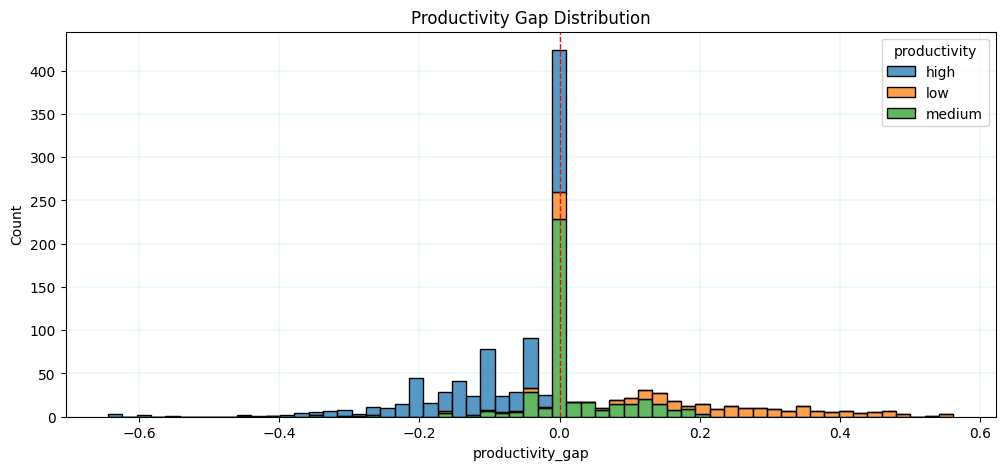

In [2904]:
plt.figure(figsize=(12,5))
sns.histplot(data=data_eda, x="productivity_gap", hue="productivity", multiple="stack")
plt.title("Productivity Gap Distribution")
plt.axvline(0, color="r", linestyle="--", linewidth=1)
plt.grid(color="c", linestyle="-", linewidth=0.1)
plt.show()

**The reason why I did the plot above was because I wanted to understand my dataset better and find out how the productivity gap would affect the actual productivity.**

**I found that if the productivity score was in the negative, it means that the productivity score was high and the productivity target was achieved by the team.If the productivity gap was positive, it means that the productivity score was low and the productivity target was not achieved by the team. Whereas at a productivity gap of 0, most of the productivity is medium. All these are highly expected results.**

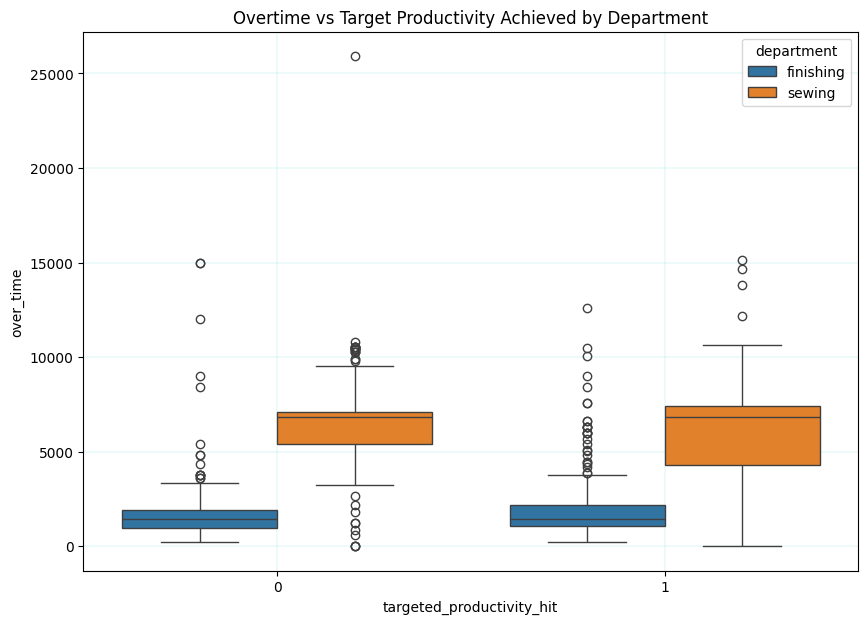

In [2862]:
sns.boxplot(data = data_eda, x="targeted_productivity_hit", y="over_time", hue="department")
plt.title("Overtime vs Target Productivity Achieved by Department")
plt.grid(color="c", linestyle="-", linewidth=0.1)

**The reason why I plotted the graph above was because I wanna find out that if the amount of overtime done by the each department and it's various team of workers affected the productivity, whether the target productivity was hit or not. If the targed_productivity was hit, it could mean that could be a higher correlation between overtime per department vs whether the targetted-productivity was hit.  As the ratio of targeted_productivity being hit and not hit are very similar, this is not useful to predict productivity.**

<Axes: title={'center': 'Productivity score by Department in Numbers'}, xlabel='productivity', ylabel='count'>

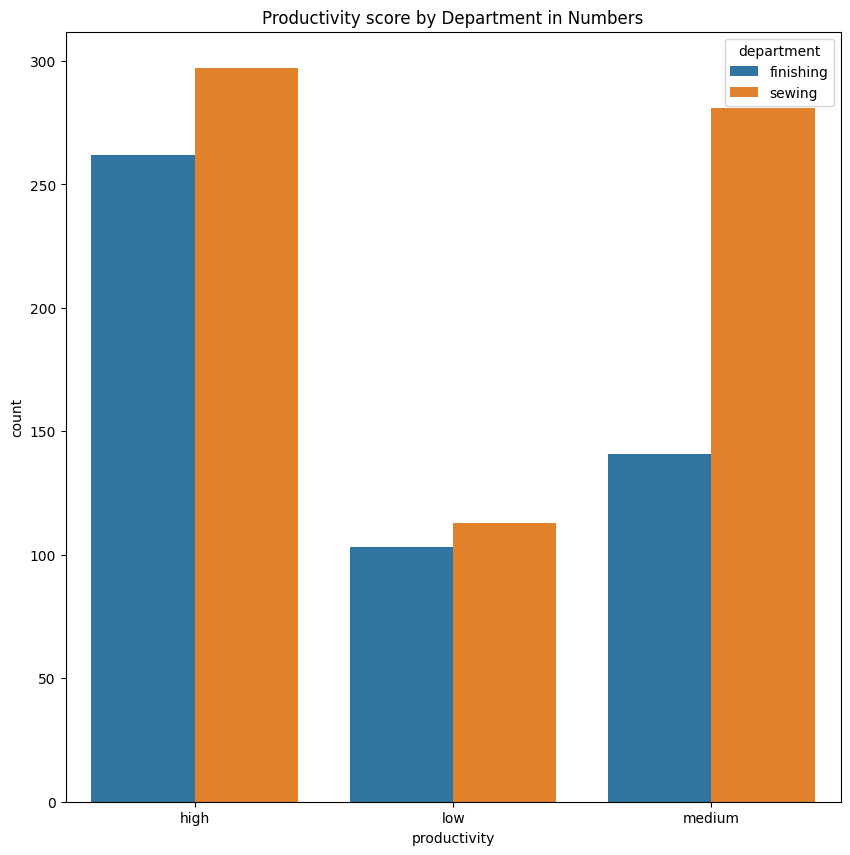

In [2906]:
plt.figure(figsize=(10, 10))
plt.title("Productivity score by Department in Numbers")
sns.countplot(x="productivity", hue ="department", data = data)

<Axes: title={'center': 'Productivity score by Department in Percentage'}, xlabel='productivity', ylabel='percent'>

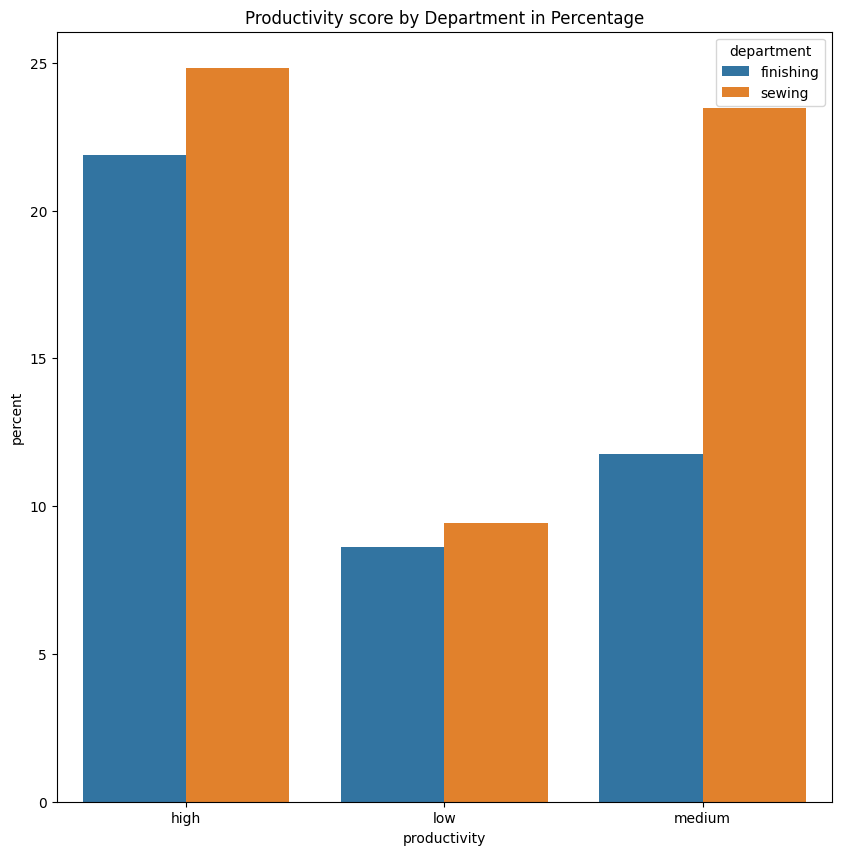

In [4064]:
plt.figure(figsize=(10, 10))
plt.title("Productivity score by Department in Percentage")
sns.countplot(data, x="productivity", hue="department", stat="percent")

**I made the 2 charts above to see if the 2 different department have different productivity score and if it is easier to score a higher productivity. From what I can see, the Sewing Department has a high count of around 280 for the high productivity score and a high count of around 270 for the medium score, whie having a low count of around 120 for the low productivity score. Whereas, the finishing department have high percentage of high compared to it's medium and high score. This means that productivity score is affected by department and I should use it as an input variable to predict productivity.**

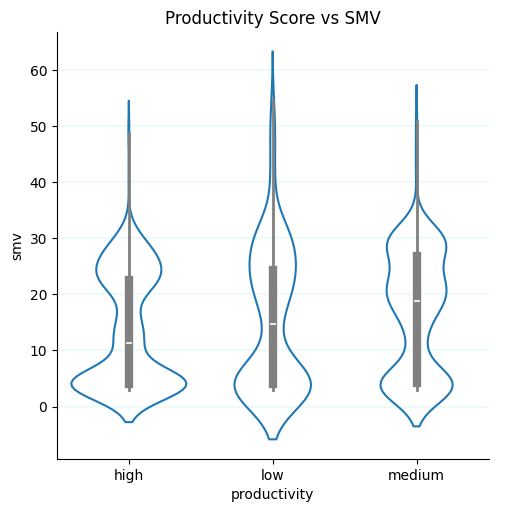

In [2863]:
sns.catplot(data=data, x="productivity", y="smv", kind="violin", inner_kws=dict(box_width=6, color="0.5"), fill=False)
plt.title("Productivity Score vs SMV")
plt.grid(axis ="y", color="c", linestyle="-", linewidth=0.1)

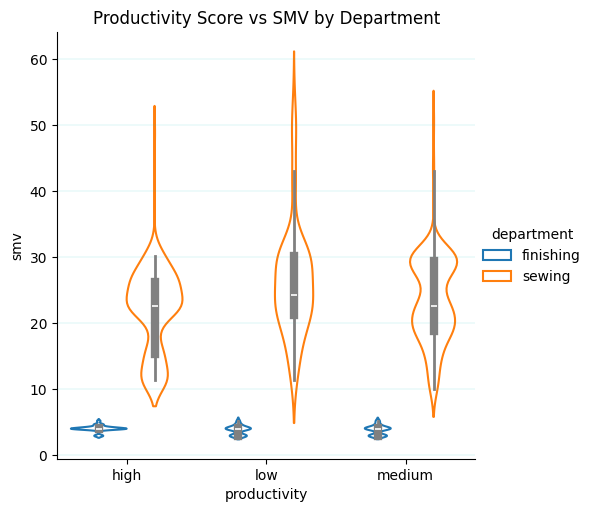

In [2864]:
sns.catplot(data=data, x="productivity", y="smv", hue="department", kind="violin", inner_kws=dict(box_width=6, color="0.5"), fill=False)
plt.title("Productivity Score vs SMV by Department")
plt.grid(axis ="y", color="c", linestyle="-", linewidth=0.1)

**I've plotted these two graphs because I want to find out if there's a correlation between smv and productivity. My initial theory was that the higher the SVM, the lower the productivity. Which from the insight, I can tell it's slightly true because the higher the peak values, the lower the productivity score.**

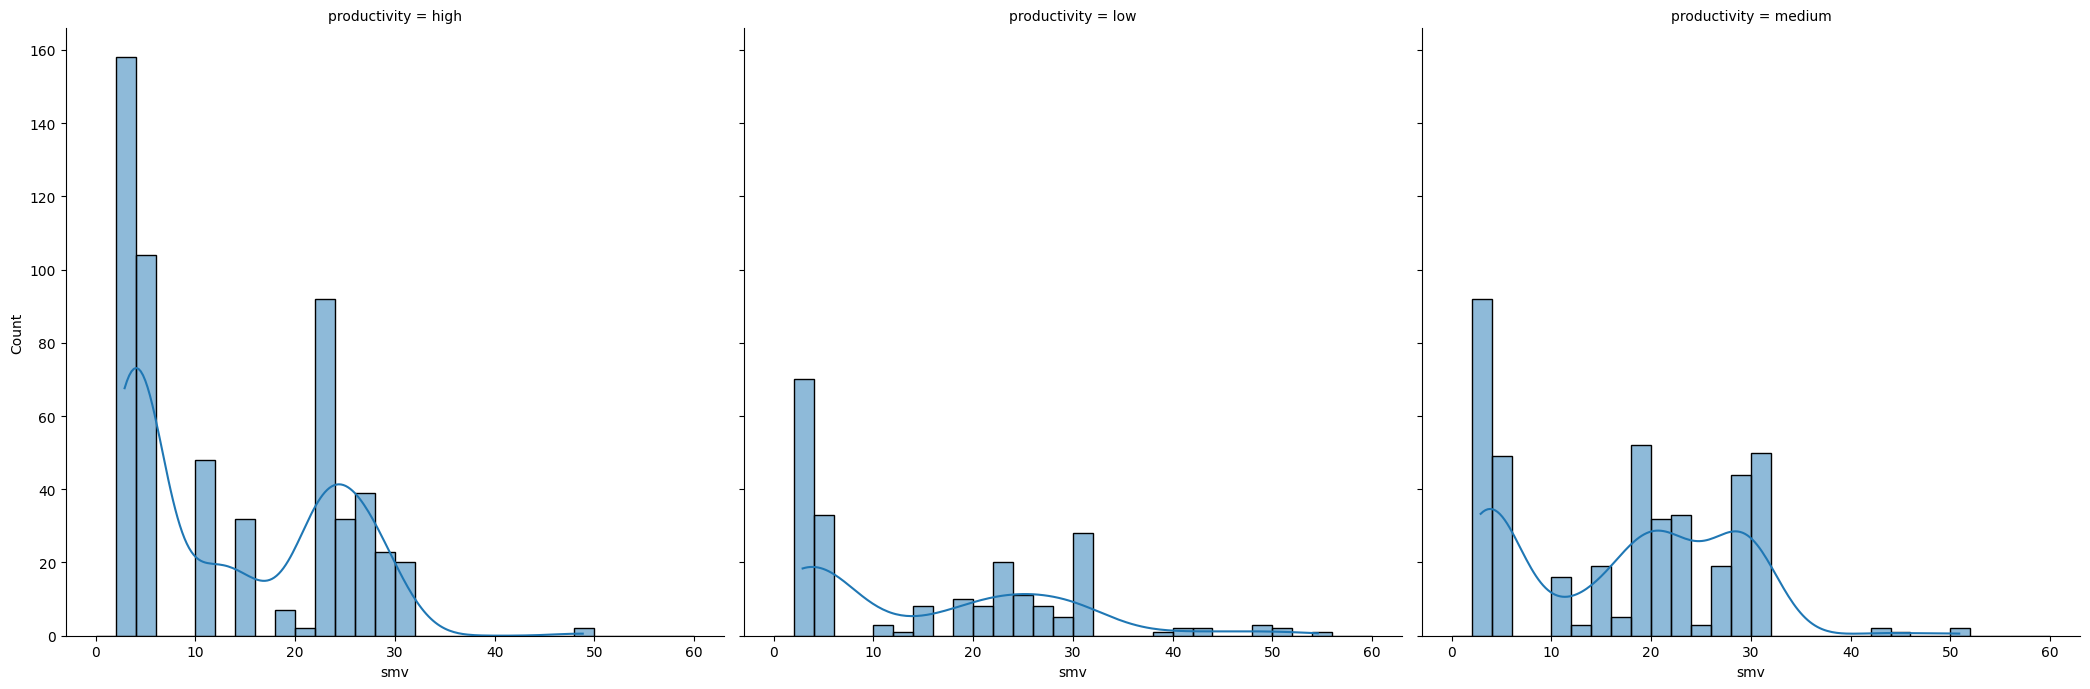

In [2629]:
p_smv = sns.FacetGrid(data, col="productivity",height=7)
p_smv.map_dataframe(sns.histplot, x="smv", binwidth=2, binrange=(0, 60), kde=True)

Text(0.5, 1.0, 'WIP vs SMV')

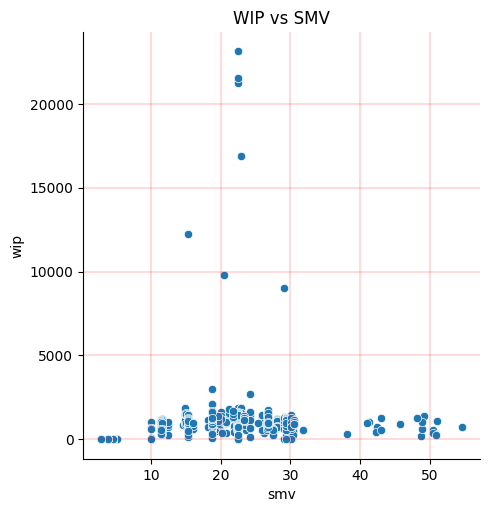

In [3840]:
p_smv_wip = sns.FacetGrid(data, height=5)
p_smv_wip.map_dataframe(sns.scatterplot, x="smv", y="wip")
plt.grid(color="r", linestyle="-", linewidth=0.2)
plt.title("WIP vs SMV")

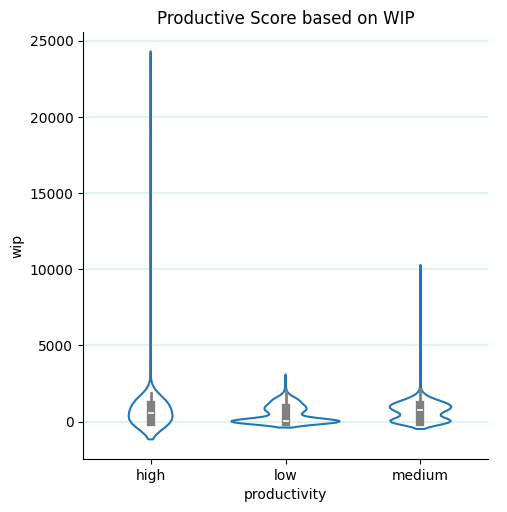

In [2630]:
sns.catplot(data=data, x="productivity", y="wip", kind="violin", inner_kws=dict(box_width=6, color="0.5"), fill=False)
plt.title("Productive Score based on WIP")
plt.grid(axis ="y", color="c", linestyle="-", linewidth=0.2)

<Axes: title={'center': 'Productive Score based on WIP'}, xlabel='wip', ylabel='productivity'>

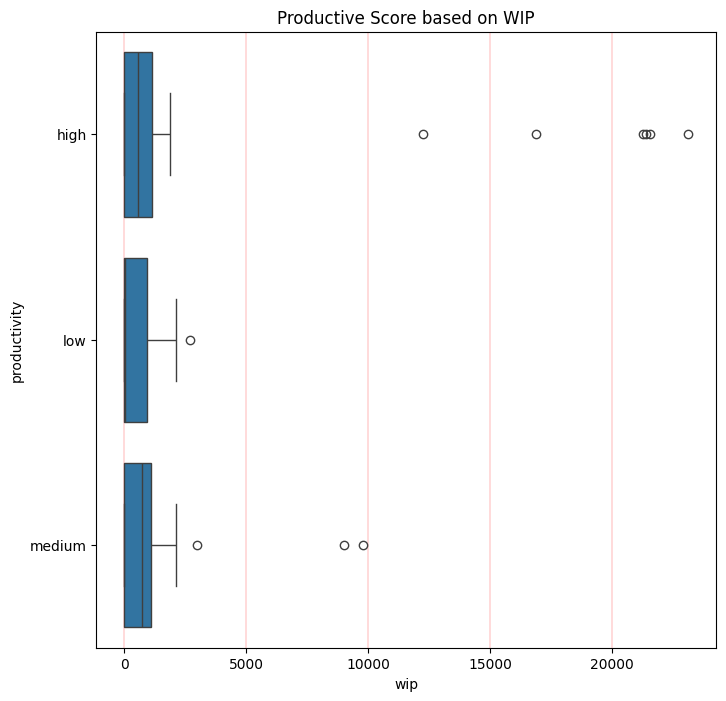

In [3940]:
plt.figure(figsize=(8, 8))
plt.title("Productive Score based on WIP")
plt.grid(axis="x", color="r", linestyle="-", linewidth=0.2)
sns.boxplot(data=data, x="wip", y="productivity")

**The reason why I made these charts above because I want to find out if there's any relationship between work in progress and productivity score. But from what I can tell, there is not much of correlation except for the outliers. For the high productivity score, there are multiple outliers above the of 10,000 mark. Additionally, I wanted to see whether there is any correlation between the work in progress and standard minute value compared to productivity score. I was... But from what you can tell from these charts above, there is no clear correlation. Hence, trial and error for feature selection must be done.**

Text(0.5, 1.0, 'Productivity Score vs Targeted Productivity')

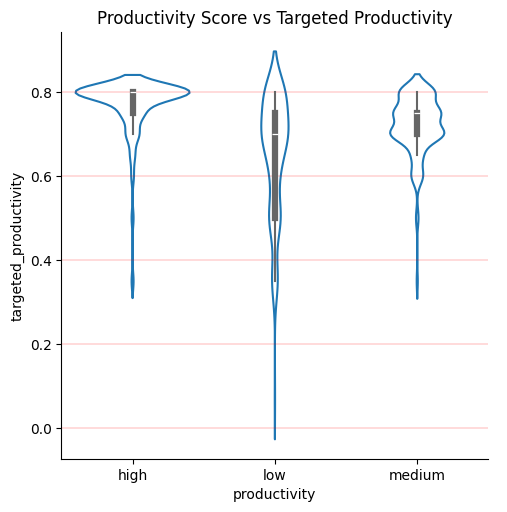

In [3839]:
sns.catplot(data=data, x="productivity", y="targeted_productivity", kind="violin", inner_kws=dict(box_width=4.5, color="0.4"), fill=False)
plt.grid(axis="y", color="r", linestyle="-", linewidth=0.2)
plt.title("Productivity Score vs Targeted Productivity")

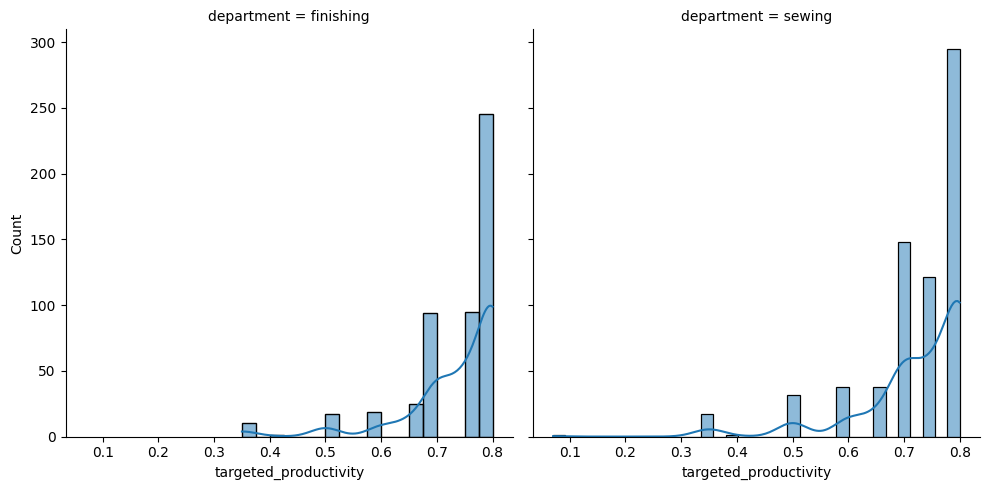

In [2632]:
p_prod = sns.FacetGrid(data, col="department", height=5, aspect=1)
p_prod.map(sns.histplot, "targeted_productivity", kde=True)

**From the two charts above, I wanted to tell if the higher the Target Productivity Score per Department, the higher the chance of scoring a higher Productivity Score. As from the 1st chart, the high productivity score has most of it's data points around 80% mark for targeted productivity, medium productivity score having the most data points around the high 60% to low 80% mark, whereas the low productivity score has most of it's data points spread out and targetted productivity score being very low as seen in the violin plot.**

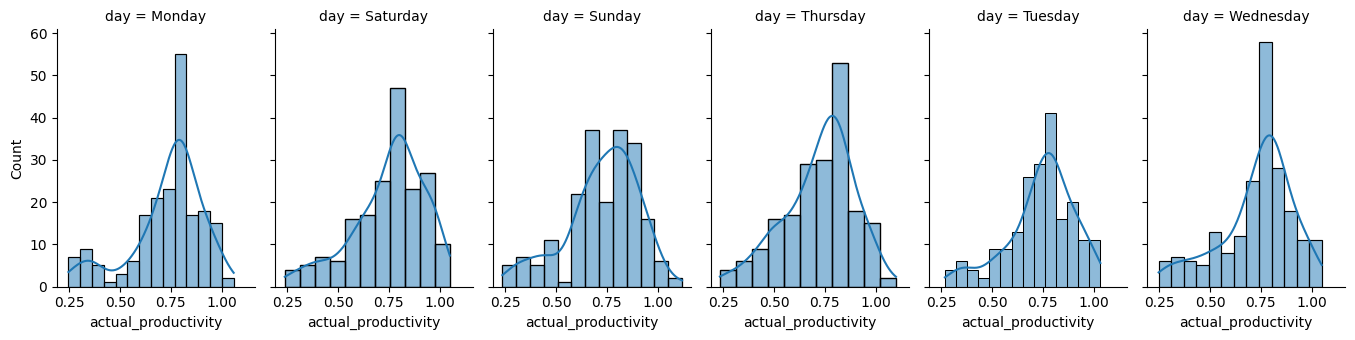

In [2633]:
p_day = sns.FacetGrid(data, col="day", height=3.5, aspect=.65)
p_day.map(sns.histplot, "actual_productivity", kde=True)

**The reason why I created this plot is because I want to find out if there is any burnout from the workers working six days in a week. And from what I can tell, there is not much impact on productivity score depending on which day of the week it is that they are working on.**

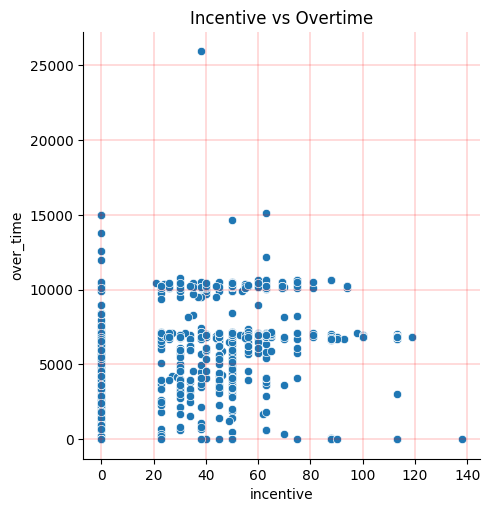

In [2638]:
p_incent = sns.FacetGrid(data, height=5)
p_incent.map_dataframe(sns.scatterplot, x="incentive", y="over_time")
plt.title("Incentive vs Overtime")
plt.grid(color="r", linestyle="-", linewidth=0.2)

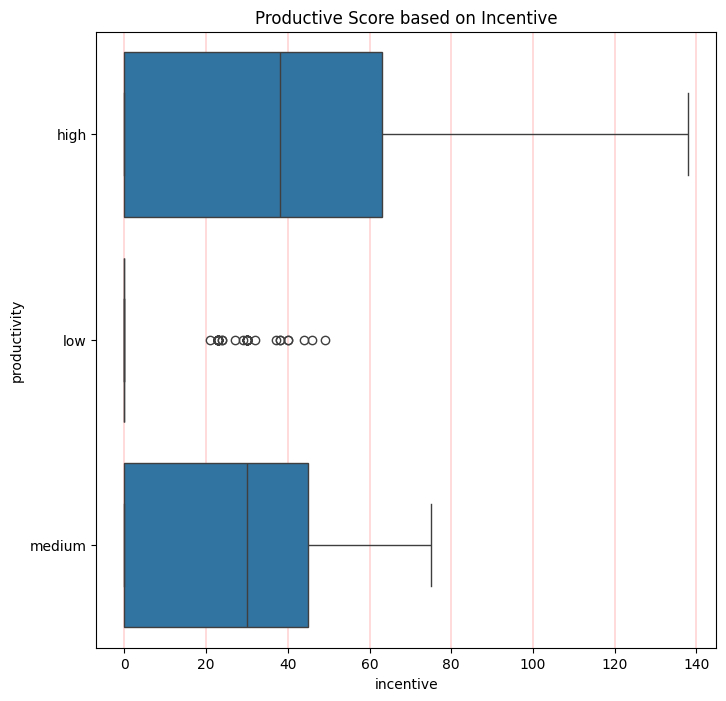

In [2639]:
plt.figure(figsize=(8, 8))
plt.title("Productive Score based on Incentive")
sns.boxplot(data=data, x="incentive", y="productivity")
plt.grid(axis = "x", color="r", linestyle="-", linewidth=0.2)

**I made these 2 chart because I wanna find out if incentive will motivate the workers to do work harder and work overtime, and as a result increase productivity. And according to this chart, I was right. Hence I found out that incentive would be a good input variable to predict productivity.**

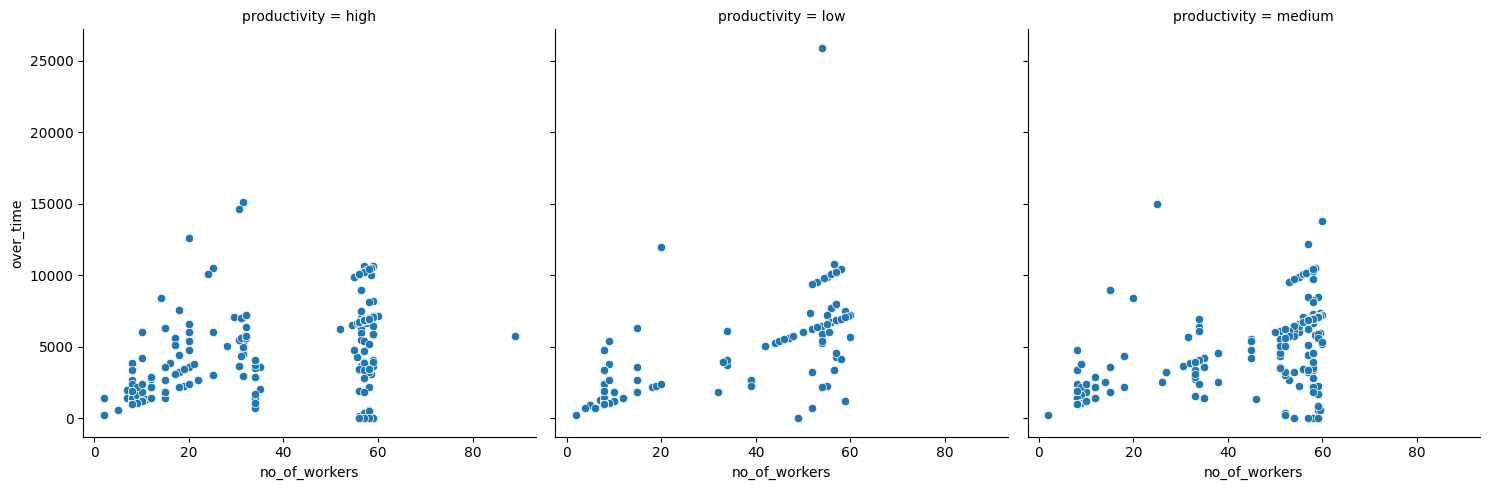

In [2640]:
p_incent = sns.FacetGrid(data, col="productivity", height=5)
p_incent.map_dataframe(sns.scatterplot, x="no_of_workers", y="over_time")

**From this chart, I got on this chart to see whether the number of overtime per number of worker would affect how high the productivity score is. And I found out that all of them do equally the same. So this infomation is not useful to determine productivity.**

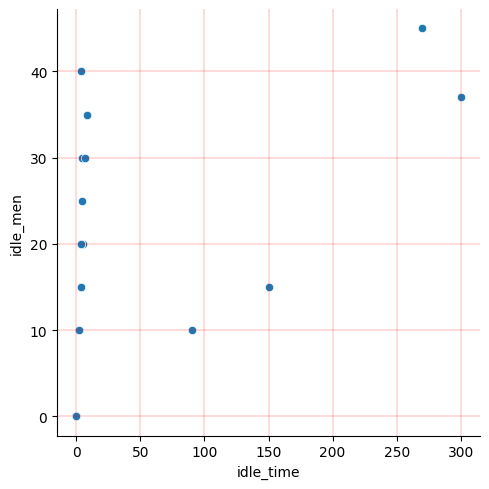

In [2636]:
p_idle0 = sns.FacetGrid(data, height=5)
p_idle0.map_dataframe(sns.scatterplot, x="idle_time", y="idle_men")
plt.grid(color="r", linestyle="-", linewidth=0.2)

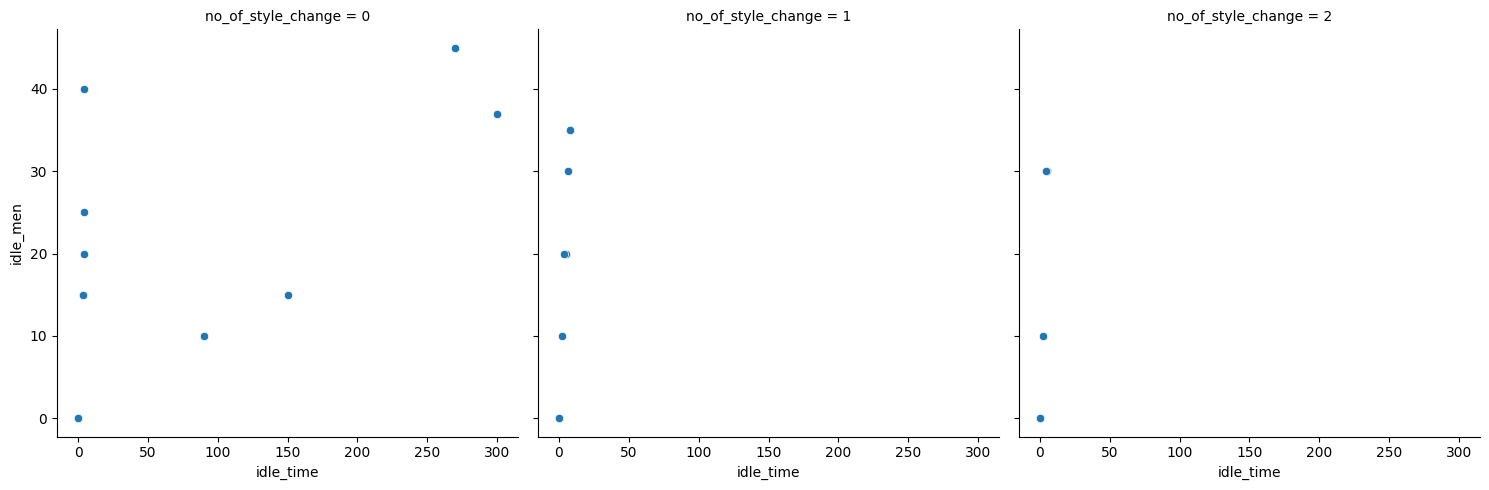

In [2641]:
p_incent = sns.FacetGrid(data, col="no_of_style_change", height=5)
p_incent.map_dataframe(sns.scatterplot, x="idle_time", y="idle_men")

In [2642]:
print("Records with idle_men:", (data["idle_men"]!=0).sum())
print("Records with idle_time:", (data["idle_time"]!=0).sum())
data[(data["idle_men"] != 0) & (data["idle_men"] != 0)]

Records with idle_men: 18
Records with idle_time: 18


,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity,productivity,targeted_productivity_hit,productivity_gap
615,2015-02-04,Quarter1,sewing,Wednesday,5,0.65,30.10,326.0,5820,0,90.0,10,0,58.5,0.650835,medium,1,-0.000835
617,2015-02-04,Quarter1,sewing,Wednesday,4,0.35,30.10,287.0,6060,23,150.0,15,0,55.5,0.350706,low,1,-0.000706
650,2015-02-07,Quarter1,sewing,Saturday,7,0.70,24.26,658.0,6960,0,270.0,45,0,58.0,0.662270,medium,0,0.037730
654,2015-02-07,Quarter1,sewing,Saturday,8,0.70,24.26,652.0,6840,0,300.0,37,0,57.0,0.365319,low,0,0.334681
775,2015-02-15,Quarter3,sewing,Sunday,8,0.70,30.10,507.0,5880,40,2.0,10,1,59.0,0.700573,medium,1,-0.000573
798,2015-02-16,Quarter3,sewing,Monday,8,0.70,30.10,7.0,7080,27,2.0,10,2,59.0,0.621972,medium,0,0.078028
818,2015-02-17,Quarter3,sewing,Tuesday,8,0.60,29.40,179.0,0,23,5.0,30,2,58.0,0.600983,medium,1,-0.000983
822,2015-02-17,Quarter3,sewing,Tuesday,10,0.65,18.22,741.0,0,0,8.0,35,1,49.0,0.302117,low,0,0.347883
841,2015-02-18,Quarter3,sewing,Wednesday,10,0.70,19.68,1119.0,5640,0,8.0,35,1,47.0,0.303574,low,0,0.396426
843,2015-02-18,Quarter3,sewing,Wednesday,8,0.65,29.40,962.0,4560,0,4.5,30,2,57.0,0.251399,low,0,0.398601


**From the three informatic charts above, I can tell that there are only 18 idle men and 18 idle time columns. 18 out of 1,197 rows does not do that much and does not have a lot of effect on the productivity outcome. But I will still use it as a variable as it could still have a small impact on productivity. If the amount of idle men or idle_time increase, the productivity could also decrease.**

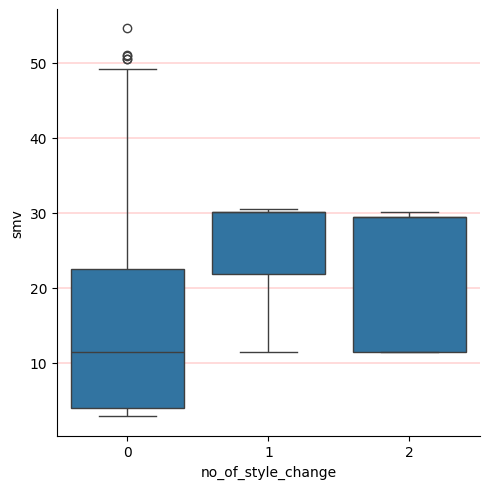

In [2643]:
p_style = sns.FacetGrid(data, height=5)
p_style.map_dataframe(sns.boxplot, x="no_of_style_change", y="smv")
plt.grid(axis ="y", color="r", linestyle="-", linewidth=0.2)

**I made this chart because I want to find out if the number of style changes would affect the standard minute value. Wondering if the style change will affect the standard minute value. I found out that having a style change would cause the maxim standard minute value to be lower. And it made me realise that the reason it drops is because the workers have probably found a faster way to work on the products. By being able to work on the product faster means there is an increased chance of achieving a higher productivity score.**

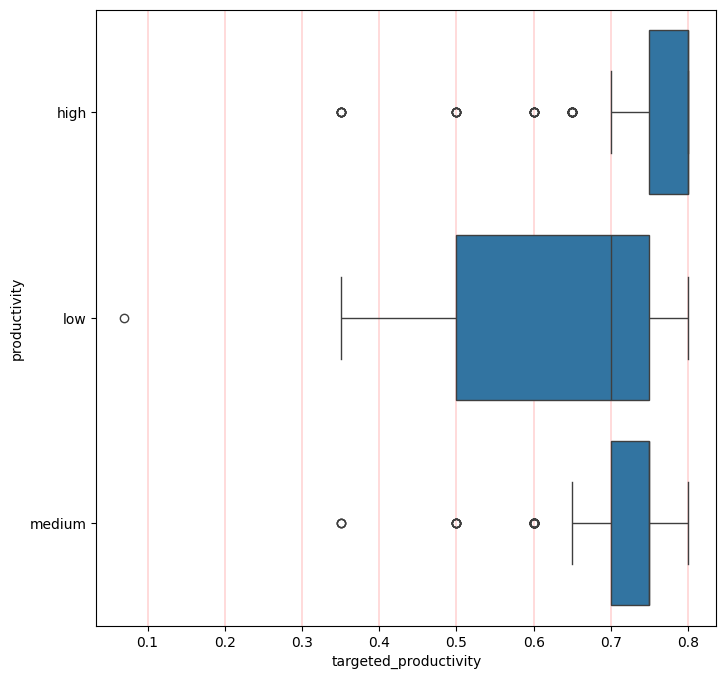

In [2644]:
plt.figure(figsize=(8, 8))
sns.boxplot(data=data, x="targeted_productivity", y="productivity")
plt.grid(axis="x", color="r", linestyle="-", linewidth=0.2)

**From this chart, I found that the higher the target_productivity score set, the higher the productivity score. Hence, I figured that I should use target productivity as one of the input variables to predict productivity.**

## **Feature engineering for input variables** ##

In [4065]:
#duplicate the original cleaned data
#Did not include the feature engineering with in the original cleaned dataset as I want to test the models with my original cleaned dataset.
data_upgrade = data.copy()

In [4066]:
data_upgrade["over_time_effectiveness"]= (data["over_time"] / (data["over_time"] + data["idle_time"] + 1)) 
#np.where help to filter out the over_time values which are 0 and fill the over_time_effectiveness with 0 instead.

**I created the over_time_effective variable to see what is the true over_time amount after accounting for the idle_time taken that day by each team and it's relevant department for that day. If the over_time period is 0, the over_time_effectiveness is set to 0 as there was no valid over_time.**

In [4067]:
data_upgrade["wip_per_worker"] = np.where(data["wip"] !=0, (data["wip"]/data["no_of_workers"]), 0)

**I created the wip_per_worker variable to see whether the average work in progress taken by each worker affect productivity or not. I made this variable wondering if the more wip (more products are worked on, that hasn't reached the finishing department yet) by each worker which mean a higher productivity. If the wip is 0, the wip_per_worker is set to 0 as there was no wip in the finishing department.**
**Note: In the finishing department, there is no wip as the products will be completed in the finishing state and will hence not be classified as "work-in-progress".**

In [4068]:
data_upgrade["idle_min_per_worker"]= np.where(data["idle_time"] != 0, (data["idle_time"])/data["idle_men"], 0) 
#np.where help to filter out the idle_time and idle_men values which are 0 and fill the idle_min_per_worker with 0 instead.
#I only used data["idle_time"] != 0 as the rows which data["idle_men"] != 0 are the same.
pd.unique(data_upgrade["idle_min_per_worker"]) #line for checking the unique variables

array([ 0.        ,  9.        , 10.        ,  6.        ,  8.10810811,
        0.2       ,  0.16666667,  0.22857143,  0.15      ,  0.23333333,
        0.25      ,  0.175     ,  0.18      ,  0.21666667,  0.1       ])

**I created the idle_min_per_worker variable as I wanted to see know the effect of idle time per idle worker on productivity. If the other time per worker is higher, I would assume that the worker's productivity would decrease. If the idle_min is 0, then the idle_min_per_worker will be 0 as there is no idle time.**

In [4069]:
data_upgrade["overtime_dependency"] = (data["over_time"] / (data["over_time"] + data["smv"] + 1))

**I created the overtime_dependency variable as I wanted to see how dependent the team relys on overtime to complete an expected amount of products and how it will affect the productivity output.**

In [4070]:
data_upgrade["idle_impact"] = (data["idle_time"] / (data["no_of_workers"] + 1))

**I created the idle_impact variable as I wanted to see how the idle time average our between all the workers in the same team (including the workers which were not idle) would affect the productivity output.**

## **Data visualisation with feature engineered variables** ##

In [3991]:
data_upgrade.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     1197 non-null   datetime64[ns]
 1   quarter                  1197 non-null   category      
 2   department               1197 non-null   category      
 3   day                      1197 non-null   category      
 4   team                     1197 non-null   category      
 5   targeted_productivity    1197 non-null   float64       
 6   smv                      1197 non-null   float64       
 7   wip                      1197 non-null   float64       
 8   over_time                1197 non-null   int64         
 9   incentive                1197 non-null   int64         
 10  idle_time                1197 non-null   float64       
 11  idle_men                 1197 non-null   int64         
 12  no_of_style_change       1197 non-

In [3949]:
data_upgrade_dv = data_upgrade.drop(columns = ["date", "department", "team", "productivity"])
data_upgrade_dv1 = pd.get_dummies(data_upgrade_dv)
data_upgrade_dv1.corr()

,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity,...,quarter_Quarter2,quarter_Quarter3,quarter_Quarter4,quarter_Quarter5,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
targeted_productivity,1.000000,-0.069489,0.019035,-0.089312,0.216804,-0.056181,-0.053818,-0.209294,-0.084288,0.421594,...,0.015654,-0.039795,-0.078973,-0.022860,-0.001074,0.017842,0.036051,-0.040747,-0.009276,-0.002558
smv,-0.069489,1.000000,0.322704,0.673670,0.602191,0.056863,0.105901,0.315388,0.912176,-0.122089,...,-0.013198,0.036639,-0.006510,-0.018811,0.000305,-0.016807,0.004015,0.002882,0.009399,-0.000277
wip,0.019035,0.322704,1.000000,0.275929,0.387456,-0.005101,-0.007119,0.053293,0.373908,0.047389,...,-0.066126,-0.016660,-0.024055,-0.008886,0.168038,-0.036777,-0.031803,-0.032346,-0.027547,-0.039415
over_time,-0.089312,0.673670,0.275929,1.000000,0.536846,0.030946,-0.018410,0.058708,0.733113,-0.053574,...,-0.033694,0.043719,0.041591,-0.050069,-0.019678,0.015115,0.000555,0.083396,-0.018943,-0.058953
incentive,0.216804,0.602191,0.387456,0.536846,1.000000,-0.039686,-0.064840,0.004809,0.697547,0.310481,...,-0.014865,-0.037013,-0.014490,0.048271,-0.011615,0.013868,-0.022500,0.007083,0.015714,-0.002053
idle_time,-0.056181,0.056863,-0.005101,0.030946,-0.039686,1.000000,0.559146,-0.011598,0.058049,-0.080851,...,-0.035829,-0.019940,-0.028082,-0.011227,-0.025311,0.078508,-0.022906,-0.023456,-0.022388,0.017463
idle_men,-0.053818,0.105901,-0.007119,-0.018410,-0.064840,0.559146,1.000000,0.133632,0.106946,-0.181734,...,-0.070447,0.072232,-0.029381,-0.022075,-0.043594,0.009119,0.010247,0.001042,0.014213,0.008903
no_of_style_change,-0.209294,0.315388,0.053293,0.058708,0.004809,-0.011598,0.133632,1.000000,0.327787,-0.207366,...,-0.014690,0.074066,0.191381,-0.068688,-0.004852,-0.011408,-0.033972,0.021382,0.009273,0.019187
no_of_workers,-0.084288,0.912176,0.373908,0.733113,0.697547,0.058049,0.106946,0.327787,1.000000,-0.057991,...,-0.024557,0.038056,-0.004250,-0.025979,0.005829,-0.021575,-0.006652,0.015184,0.007546,-0.000830
actual_productivity,0.421594,-0.122089,0.047389,-0.053574,0.310481,-0.080851,-0.181734,-0.207366,-0.057991,1.000000,...,0.030805,-0.080219,-0.076275,0.102019,0.001017,0.041539,-0.016808,-0.031875,0.019600,-0.012172


## **Setting input and target variables** ##

In [1656]:
#Set productivity as the target variable and encode it
#I used label encoded for the target so that I have 1 column as the target instead of 3
le = preprocessing.LabelEncoder()
ycoded = le.fit_transform(data["productivity"])
print(data["productivity"])
print(ycoded)
#After doing the label encoding, I can tell that high is encoded as 0, medium is encoded as 1 and low is encoded as 2

0         high
1         high
2         high
3         high
4         high
         ...  
1192    medium
1193    medium
1194    medium
1195       low
1196       low
Name: productivity, Length: 1197, dtype: category
Categories (3, object): ['high', 'low', 'medium']
[0 0 0 ... 2 1 1]


**Set input variables into X**

I decided to include all my variables except date, actual_productivity and productivity as my input variables. 

I did not include the date as it is not useful, the productivity column is the target variable, and including the actual_productivity column will cause the model to be extremely accurate, as actual_productivity is just a percentage version of the productivity column.

In [1657]:
data_input = data.drop(columns = ["date", "actual_productivity", "productivity"])

#Encode all the categorical data (2nd data transformation)
X_encoded = pd.get_dummies(data_input, dtype=int)
print(X_encoded[:])
X_encoded.info()

      targeted_productivity    smv     wip  over_time  incentive  idle_time  \
0                      0.80  26.16  1108.0       7080         98        0.0   
1                      0.75   3.94     0.0        960          0        0.0   
2                      0.80  11.41   968.0       3660         50        0.0   
3                      0.80  11.41   968.0       3660         50        0.0   
4                      0.80  25.90  1170.0       1920         50        0.0   
...                     ...    ...     ...        ...        ...        ...   
1192                   0.75   2.90     0.0        960          0        0.0   
1193                   0.70   3.90     0.0        960          0        0.0   
1194                   0.65   3.90     0.0        960          0        0.0   
1195                   0.75   2.90     0.0       1800          0        0.0   
1196                   0.70   2.90     0.0        720          0        0.0   

      idle_men  no_of_style_change  no_of_workers  

In [1658]:
#Normalising X_encoded values
X_encoded = (X_encoded - X_encoded.min(0)) / np.ptp(X_encoded, axis = 0)
print(X_encoded)

      targeted_productivity       smv       wip  over_time  incentive  \
0                  1.000000  0.450252  0.047920   0.273148   0.710145   
1                  0.931507  0.020132  0.000000   0.037037   0.000000   
2                  1.000000  0.164731  0.041865   0.141204   0.362319   
3                  1.000000  0.164731  0.041865   0.141204   0.362319   
4                  1.000000  0.445219  0.050601   0.074074   0.362319   
...                     ...       ...       ...        ...        ...   
1192               0.931507  0.000000  0.000000   0.037037   0.000000   
1193               0.863014  0.019357  0.000000   0.037037   0.000000   
1194               0.794521  0.019357  0.000000   0.037037   0.000000   
1195               0.931507  0.000000  0.000000   0.069444   0.000000   
1196               0.863014  0.000000  0.000000   0.027778   0.000000   

      idle_time  idle_men  no_of_style_change  no_of_workers  \
0           0.0       0.0                 0.0       0.65517

## **Logistic Regression** ##

In [2547]:
classifier = LogisticRegression(solver= "liblinear", random_state = 0)
classifier.fit(X_encoded,ycoded)
Y_pred0 = classifier.predict(X_encoded)
accuracy = metrics.accuracy_score(ycoded, Y_pred0)
print('train accuracy: %.2f.' %accuracy)
print("\n")
precision = metrics.precision_score(ycoded, Y_pred0, average ="micro")
print('train precision: %.2f.' %precision)
print("\n")
recall = metrics.recall_score(ycoded, Y_pred0, average ="micro")
print('train recall: %.2f.' %recall)
print(Y_pred0)

train accuracy: 0.65.


train precision: 0.65.


train recall: 0.65.
[0 0 2 ... 0 0 0]


**I chose the average to be micro for both the precision_score and recall_score for the code block above, as it gave me the best train precision and recall score.**

## **Reason for not choosing Logistic Regression as the final multi-class classification model** ##
**I also did not continue on with Logistic Regression as the accuracy rate is not at least 70%, the accuracy is only 65%**

## **SVM Model** ##

In [3769]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, ycoded, test_size = 0.25, stratify= ycoded)

print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(897, 34)
(300, 34)
(897,)
(300,)


**Testing linear kernel**

In [3770]:
model = SVC(kernel='linear', C=100)
model.fit(X_train,y_train)

,C,100
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [3771]:
y_pred = model.predict(X_test)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.66


**After some trial and errors, I have found that my average accuracy score is the highest with a test size of 0.25 and a C value of 100 for the linear kernel**

**Testing rbf kernel**

In [3772]:
model1 = SVC(kernel='rbf', C=10, decision_function_shape = 'ovo', gamma = 0.1)
model1.fit(X_train,y_train)

,C,10
,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [3773]:
y_pred1 = model1.predict(X_test)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred1))

Accuracy: 0.66


**After some trial and errors, I have found that my average accuracy score is the highest with a test size of 0.25, the decision function shape to be "ovo", and a C value of 10 for rbf kernel**

## **Insights**
***SVM Model insights:***

**From the testing above, I have found out that the best settings for a more accurate model is a 'rbf' kernel with a test size of 25, a C value of 10, a decision function shape of ovo and the gamma value of 0.1** 
**However, I will be using the linear SVC kernel with a C parameter of 100, as it gave me a better average compared to the "rbf" SVC kernels.**

**Currently, the best SVM model before only gave an average accuracy of 0.66470%, which is less than the  required 70% accuracy. Additionally, out of the 10 tries with the best parameters, 25% training size and a C value of 100, the model hit at least 70% only once.**

***General insights:***

**From my testing above, I found out that 25% is the most optimal test size, hence I will be using a test_size of 0.25 in the following data splits**

## **KNN Model** ##

In [3790]:
#import metrics model to check the accuracy 
from sklearn import metrics
#Try running from k=1 through 25 and record testing accuracy
k_range = range(1,25)
scores_list = []
error_list = []
train_accuracy =np.empty(len(k_range))
test_accuracy = np.empty(len(k_range))
for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k, weights='uniform')
        knn.fit(X_train,y_train)
        train_accuracy[k-1] = knn.score(X_train, y_train)
        test_accuracy[k-1] = knn.score(X_test, y_test)

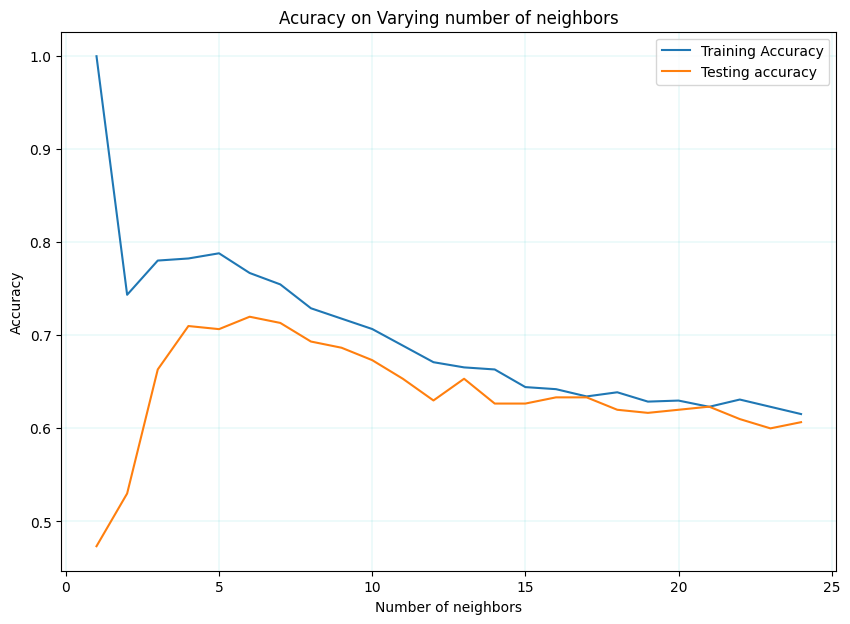

In [3793]:
plt.title('Acuracy on Varying number of neighbors')
plt.plot(k_range,train_accuracy, label='Training Accuracy')
plt.plot(k_range,test_accuracy, label='Testing accuracy')
plt.legend()
plt.xlabel('Number of neighbors')
plt.ylabel('Accuracy')
plt.grid(color="c", linestyle="-", linewidth=0.1)

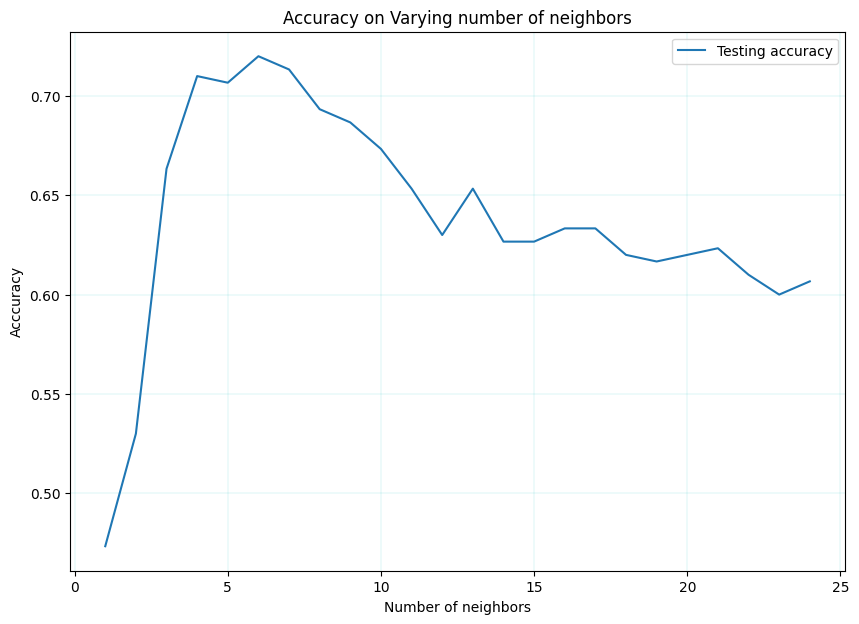

In [3795]:
plt.title('Accuracy on Varying number of neighbors')
plt.plot(k_range,test_accuracy, label='Testing accuracy')
plt.legend()
plt.xlabel('Number of neighbors')
plt.ylabel('Acccuracy')
plt.grid(color="c", linestyle="-", linewidth=0.1)

In [3796]:
#From the plot above, I can tell that the bes number of neighbors is 6
knn = KNeighborsClassifier(n_neighbors=6, weights='uniform')
knn.fit(X_train, y_train)
y_pred1=knn.predict(X_test)


print(metrics.accuracy_score(y_test, y_pred1))

0.72


## **KNN Insight** ##
I have found that my best number of neighbours is 6 and that it has performed slightly better than my current SVM model. I will consider the use of KNN as the final multi-class classification model.

## **Round 2 of spliting data for training and testing** ##

In [4160]:
#Encode the input data again so that it can use StandardScaler instead of normalising
X_encoded1 = pd.get_dummies(data_input, dtype=int)

In [4164]:
#Split the encoded data without normalisation into the test and training set 
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_encoded1, ycoded, test_size = 0.25, stratify= ycoded, random_state =10)

print(X_train1.shape)
print(X_test1.shape)

print(y_train1.shape)
print(y_test1.shape)

(897, 34)
(300, 34)
(897,)
(300,)


## **Boosted SVM Model** ##

In [4153]:
#Have the test and training data standardised and hyperparameters tuned to get a better SVM accuracy
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

param_grid = {
    'svc__kernel': ['linear', 'rbf'],
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': ['scale', 0.01, 0.1, 1]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train1, y_train1)

print("Best params:", grid.best_params_)
print("CV accuracy:", grid.best_score_)
print("Test accuracy:", grid.score(X_test1, y_test1))


Best params: {'svc__C': 10, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
CV accuracy: 0.7034885164494102
Test accuracy: 0.6533333333333333


## **Overall SVM Model Insight** 

**SVM is a model that I will not consider as the multi-classification model in this project, as the average accuracy of the model with standardisation instead of normalisation and the tuning of the hyper-parameter is 0.698. Although it is very close to the minimum accuracy of 70%, it did not hit at least the 70% mark.**

## **Random Forest:** ##

In [4179]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    class_weight='balanced'
)


rf.fit(X_train1, y_train1)
print("RF accuracy:", rf.score(X_test1, y_test1))


RF accuracy: 0.7833333333333333


## **Gradient Boosting:** ##

In [4180]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4
)

gb.fit(X_train1, y_train1)
print("GB accuracy:", gb.score(X_test1, y_test1))

GB accuracy: 0.7866666666666666


## **XG Boosting:** ##

In [4176]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

xgb.fit(X_train1, y_train1)
print("XGB accuracy:", xgb.score(X_test1, y_test1))

y_pred2 = xgb.predict(X_test1)

XGB accuracy: 0.78


## **Final conclusion:** ##
The best multi-class classification model is the XGBoost Model, with a current average accuracy of 0.77067

## **Insight:**
**I have found out that the models that uses the encoded data which isn't normalised is more accurate than the models that uses the normalised encoded data. Hence for my feature selection data, I will not normalise it.**

## **Feature Selection** ##

In [4071]:
data_input.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   quarter                1197 non-null   category
 1   department             1197 non-null   category
 2   day                    1197 non-null   category
 3   team                   1197 non-null   category
 4   targeted_productivity  1197 non-null   float64 
 5   smv                    1197 non-null   float64 
 6   wip                    1197 non-null   float64 
 7   over_time              1197 non-null   int64   
 8   incentive              1197 non-null   int64   
 9   idle_time              1197 non-null   float64 
 10  idle_men               1197 non-null   int64   
 11  no_of_style_change     1197 non-null   int64   
 12  no_of_workers          1197 non-null   float64 
dtypes: category(4), float64(5), int64(4)
memory usage: 89.9 KB


In [4072]:
d_input0 = data_input.drop(columns = ["day", "quarter", "idle_time", "no_of_workers", "no_of_style_change"])
X_encoded2 = pd.get_dummies(d_input0, dtype=int)

In [4073]:
#Split the encoded data without normalisation into the test and training set 
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_encoded2, ycoded, test_size = 0.25, stratify= ycoded)

print(X_train2.shape)
print(X_test2.shape)

print(y_train2.shape)
print(y_test2.shape)

(897, 20)
(300, 20)
(897,)
(300,)


In [3829]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

xgb.fit(X_train2, y_train2)
print("XGB accuracy:", xgb.score(X_test2, y_test2))

y_pred3 = xgb.predict(X_test2)

XGB accuracy: 0.8033333333333333


In [4074]:
d_input0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   department             1197 non-null   category
 1   team                   1197 non-null   category
 2   targeted_productivity  1197 non-null   float64 
 3   smv                    1197 non-null   float64 
 4   wip                    1197 non-null   float64 
 5   over_time              1197 non-null   int64   
 6   incentive              1197 non-null   int64   
 7   idle_men               1197 non-null   int64   
dtypes: category(2), float64(3), int64(3)
memory usage: 59.1 KB


The current best features to use for predictions are department, team, targeted_productivity, smv, wip, over_time, incentive and idle_men.

In [4075]:
data_features = data_upgrade.drop(columns = ["date", "actual_productivity", "productivity"])
data_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   quarter                  1197 non-null   category
 1   department               1197 non-null   category
 2   day                      1197 non-null   category
 3   team                     1197 non-null   category
 4   targeted_productivity    1197 non-null   float64 
 5   smv                      1197 non-null   float64 
 6   wip                      1197 non-null   float64 
 7   over_time                1197 non-null   int64   
 8   incentive                1197 non-null   int64   
 9   idle_time                1197 non-null   float64 
 10  idle_men                 1197 non-null   int64   
 11  no_of_style_change       1197 non-null   int64   
 12  no_of_workers            1197 non-null   float64 
 13  over_time_effectiveness  1197 non-null   float64 
 14  wip_per_

In [4103]:
d_input1 = data_features.drop(columns = ["day", "quarter", "idle_time", "no_of_workers", "no_of_style_change", 
                                        "wip_per_worker", "idle_impact",
                                        "idle_min_per_worker"])
d_input1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   department               1197 non-null   category
 1   team                     1197 non-null   category
 2   targeted_productivity    1197 non-null   float64 
 3   smv                      1197 non-null   float64 
 4   wip                      1197 non-null   float64 
 5   over_time                1197 non-null   int64   
 6   incentive                1197 non-null   int64   
 7   idle_men                 1197 non-null   int64   
 8   over_time_effectiveness  1197 non-null   float64 
 9   overtime_dependency      1197 non-null   float64 
dtypes: category(2), float64(5), int64(3)
memory usage: 77.8 KB


In [4104]:
X_encoded3 = pd.get_dummies(d_input1, dtype=int)

In [4111]:
#Split the encoded data without normalisation into the test and training set 
X_train3, X_test3, y_train3, y_test3 = train_test_split(X_encoded3, ycoded, test_size = 0.25, stratify= ycoded)

print(X_train3.shape)
print(X_test3.shape)

print(y_train3.shape)
print(y_test3.shape)

(897, 22)
(300, 22)
(897,)
(300,)


In [4112]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

xgb.fit(X_train3, y_train3)
print("XGB accuracy:", xgb.score(X_test3, y_test3))

y_pred4 = xgb.predict(X_test3)

XGB accuracy: 0.77


## **Classification Report of final best multiti-class model** ##

**The final verdict of the best model for my dataset is the XG Boost model with an average accuracy of 79.9933% and a peak accuracy of 83% after feature scaling and feature selection and rigious testing for the best hyper parameters.**

In [4211]:
#Set productivity as the target variable and encode it
#I used label encoded for the target so that I have 1 column as the target instead of 3
le = preprocessing.LabelEncoder()
ycoded_final = le.fit_transform(data["productivity"])
print(data["productivity"])
print(ycoded_final)
#After doing the label encoding, I can tell that high is encoded as 0, medium is encoded as 1 and low is encoded as 2

0         high
1         high
2         high
3         high
4         high
         ...  
1192    medium
1193    medium
1194    medium
1195       low
1196       low
Name: productivity, Length: 1197, dtype: category
Categories (3, object): ['high', 'low', 'medium']
[0 0 0 ... 2 1 1]


In [4212]:
d_input0 = data_input.drop(columns = ["day", "quarter", "idle_time", "no_of_workers", "no_of_style_change"])
X_encoded_final = pd.get_dummies(d_input0, dtype=int)

#Split the encoded data without normalisation into the test and training set 
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(X_encoded_final, ycoded_final, test_size = 0.25, stratify= ycoded_final)

print(X_train_final.shape)
print(X_test_final.shape)

print(y_train_final.shape)
print(y_test_final.shape)

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

xgb.fit(X_train_final, y_train_final)
print("XGB accuracy:", xgb.score(X_test_final, y_test_final))

y_pred_final = xgb.predict(X_test_final)


(897, 20)
(300, 20)
(897,)
(300,)
XGB accuracy: 0.79


In [4213]:
# Print classification report
print(classification_report(y_test_final, y_pred_final))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86       140
           1       0.76      0.63      0.69        54
           2       0.76      0.72      0.74       106

    accuracy                           0.79       300
   macro avg       0.78      0.75      0.76       300
weighted avg       0.79      0.79      0.79       300



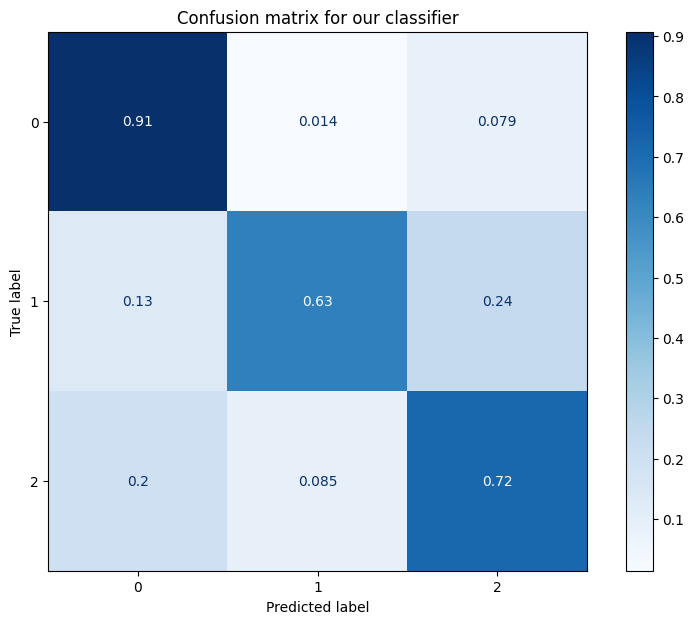

In [4214]:
#Plot the confusion matrix

matrix = ConfusionMatrixDisplay.from_predictions(y_test_final, y_pred_final, cmap=plt.cm.Blues, normalize='true')
plt.title('Confusion matrix for our classifier')

# Display the plot
plt.show()

## **Reflection on Confusion Matrix** ##

Class 0 (High Productivity)
**My best model is able to predict the high productivity score extremely well with an extremely high True Positive accuracy of 89%. The False Negative score has an extremely low score of 9.3% while the False Positive score has a vey high score of 33%.**

Class 1 (Medium Productivity)
**The model shows the weakest performance on medium productivity with a moderately with a True Positive accuracy of only 63%.
The False Negative rate is quite high at 37% (with significant leakage — 13% at high and 24% being at low), while the False Positive rate coming into class 1 is relatively low at around 10%.**

Class 2 (Low Productivity)
**The model predicts low productivity moderately well with a solid True Positive accuracy of 72%.
The False Negative rate is moderate at 28% (mainly 20% leaking into class 0), while the False Positive rate coming into class 2 is fairly high at approximately 30% (a noticeable number of high and medium cases are incorrectly predicted as low).**

## **Summary** ##

**This project focused on analyzing a Workers Productivity dataset from a factory which could be a stuff toy factory or apparel factory to build a multi-class classification model capable of predicting employee productivity levels (Low, Medium, High) with at least 70% accuracy. What was done in this workbook was the cleaning of data such as filling in the missing wip values with the value based on the context of the other columns in the missing data rows, fixing of misplaced data infomation in the wrong column in a few roles such as over_time and incentive based on the other data in the same data column, and trimmed any variables with whitespaces.**

**I then did extensive exploratory data analytics to try to understand better my dataset, and afterwards, did a bit of feature engineering with the knowledge I received from my data analysis. Next I tested out which models from the lab was able to produce the best accuracy outcome with feature scaling of the original dataset (doesn't include the feature engineered variables yet) and after testing 3, it was the Knn model with an accuracy of 71%, as the accuracy barely suppased the neccessary accuracy score requirement of 70%, and I did not know how else to improve my model, I turned to AI for assistance.**

**After some testing, I have also found out that feature scaling made my model's accuracy worse, hence I did not do any more feature scaling such as normalising from this point onwards.**

**I did not use Deep Neural Network for my project as I felt that running the model would be very time consumming and that there are better models out there. After rigious testing of the 3 new models AI has given me, I have found that my best model was the XGBoost model with the best parameter found through rigious testing among the 3 model given by AI. Afterwards, I did feature selection with my original dataset with an average accuracy of 79.9933% and a peak accuracy of 83%. Afterwards, I attempted adding all the feature engineered variables one at a time and realised that all my models performed worse than the model with the original dataset after feature selection.**

## **AI Reflection** ##

I started to use AI after creating and testing out my SVM models. I used AI as my best model (KNN)'s accuracy before I used AI was 71%, which was barely reaching the required 70% model accuracy threshold. I prompted it with my best model and accuracy when I first started using it, stating that I was doing an AIML project and that I was doing a multi-classification model. I requested that it suggests to me better models to achieve a higher accuracy of 80% or while giving it a brief analysis of all my data columns and the data info such as datatype and number of rows.

Afterwards, after AI has suggested to me 3 models and given me the code to use and test them, I updated it with my new accuracy score and asked for futher suggestions to try to improve the model's accuracy. As the further suggestions given wasn't helpful, I concluded that this was probably the highest accuracy my model could achieve.

# **References** #


1. TP AIML Reference materials 
2. TP AIML Lecture Slides (The ones in the OneDrive)
3. To convert object data types to category data type using Astype:    https://pandas.pydata.org/pandas-docs/stable/user_guide/categorical.html#:~:text=Analogously%2C%20all%20columns%20in%20an%20existing%20DataFrame%20can%20be%20batch%20converted%20using%20DataFrame.astype()%3A
4. To convert the date from object datatype to datetime datatype:      https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.to_datetime.html#pandas.to_datetime
5.  Dropping column:     https://www.youtube.com/watch?v=bDhvCp3_lYw&t=261s
6.  EDA:        https://www.youtube.com/watch?v=Liv6eeb1VfE
7.  Sorting numpy values    https://www.w3schools.com/python/numpy/numpy_array_sort.asp
8.  Searching through an array for a value https://www.w3schools.com/python/numpy/numpy_array_search.asp
9.  Grid Lines for charts: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.grid.html#matplotlib.axes.Axes.grid
10.  Pie chart: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.pie.html#matplotlib.axes.Axes.pie
11.  sklearn metrics.precision_score for the logistic regression part  https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html#sklearn.metrics.precision_score
12.  sklearn metrics.recall_score for the logistic regression part  https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html#sklearn.metrics.recall_score
13.  All of the seaborn charts: https://seaborn.pydata.org/generated/seaborn.FacetGrid.html
14.  Saving and exporting the cleaned dataset as a CSV file. https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html